## Descrição do Dataset

Nome: Planos De Ação Nacional Para A Conservação Das Espécies Ameaçadas De Extinção (PAN) 
<br>
<br>
Link: [https://dados.gov.br/dados/conjuntos-dados/planos-de-acao-nacional-para-a-conservacao-das-especies-ameacadas-de-extincao-pan]
<br>
<br>
órgão Responsável: Instituto Chico Mendes de Conservação da Biodiversidade - ICMBio
<br>
<br>
Descrição do tema: Dados sobre os Planos de Ação Nacionais para a Conservação de Espécies Ameaçadas de Extinção (PAN), como por exemplo as espécies contempladas, os biomas, abrangência, atos legais, vigência, site, dentre outras informações correlatas.
<br>
<br>
Número de Registros e Colunas: 117 registros, 21 colunas
<br>
<br>
Variáveis imporantes: panInicioAno e panFimAno, representam o início do plano e o fim do mesmo, respectivamente.

# Exploração Estatística: Planos de Ação Nacional (PAN)

Nesta análise, vamos importar as bibliotecas e definir os parâmetros iniciais.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

input_csv = r"Planos De Ação Nacional Para A Conservação Das Espécies Ameaçadas De Extinção (PAN) - 2025 CSV_CLEANED.csv"

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


## 1. Carregamento e Inspeção dos Dados

Carregando os dados e checando os tipos e valores nulos.

In [ ]:
df = pd.read_csv(input_csv, sep=';', encoding='utf-8-sig')

print("--- Informações Gerais e Tipos de Dados ---")
df.info()

print("\n--- Valores Ausentes por Coluna ---")
print(df.isnull().sum())

--- Informações Gerais e Tipos de Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 21 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   idPan                                                                        117 non-null    str    
 1   panNome                                                                      117 non-null    str    
 2   panNomeCompleto                                                              117 non-null    str    
 3   idPan2                                                                       117 non-null    str    
 4   panNomeFantasia                                                              117 non-null    str    
 5   panAbrangenciaTaxonomica                                                     117 non-null    str    
 6   panAbrang

## 2. Tratamento e Conversão Numérica

Garantindo que os anos de início e fim sejam numéricos.

In [ ]:
df['panInicioAno'] = pd.to_numeric(df['panInicioAno'], errors='coerce')
df['panFimAno'] = pd.to_numeric(df['panFimAno'], errors='coerce')

num_cols = ['panInicioAno', 'panFimAno']
df[num_cols].head(5)

,panInicioAno,panFimAno
0,2004.0,2014.0
1,2006.0,2006.0
2,2006.0,2011.0
3,2006.0,2011.0
4,2006.0,2016.0


## 3. Estatísticas Descritivas

Calculando média, mediana, moda, quartis e etc.

In [7]:
for col in num_cols:
    print(f"\nEstatísticas para: {col}")
    data = df[col].dropna()
    
    media = data.mean()
    mediana = data.median()
    moda = data.mode()
    minimo = data.min()
    maximo = data.max()
    desvio = data.std()
    variancia = data.var()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    print(f"Média: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Moda: {moda.tolist()}")
    print(f"Mínimo: {minimo}")
    print(f"Máximo: {maximo}")
    print(f"Desvio Padrão: {desvio:.2f}")
    print(f"Variância: {variancia:.2f}")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"IQR: {iqr:.2f}")


Estatísticas para: panInicioAno
Média: 2016.29
Mediana: 2017.00
Moda: [2010.0]
Mínimo: 2004.0
Máximo: 2025.0
Desvio Padrão: 5.65
Variância: 31.94
Q1 (25%): 2012.00
Q3 (75%): 2021.25
IQR: 9.25

Estatísticas para: panFimAno
Média: 2021.49
Mediana: 2022.00
Moda: [2023.0]
Mínimo: 2006.0
Máximo: 2030.0
Desvio Padrão: 5.53
Variância: 30.57
Q1 (25%): 2017.00
Q3 (75%): 2026.25
IQR: 9.25


## 4. Visualizações Estatísticas

Histogramas, Boxplots e Scatter Plot visando capturar dispersão e correlação.

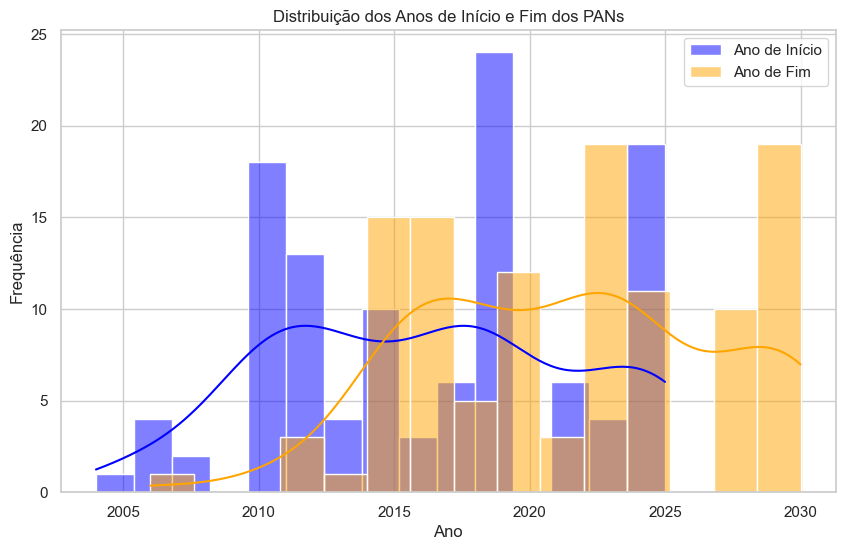

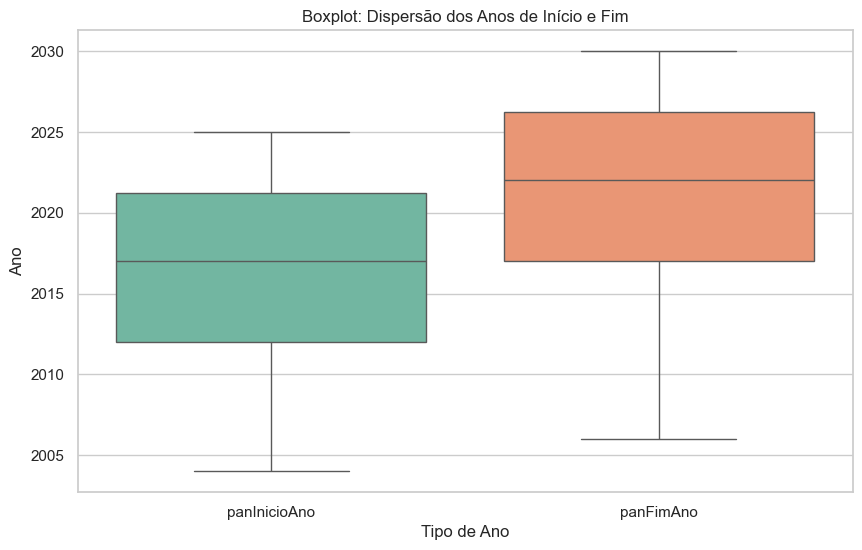

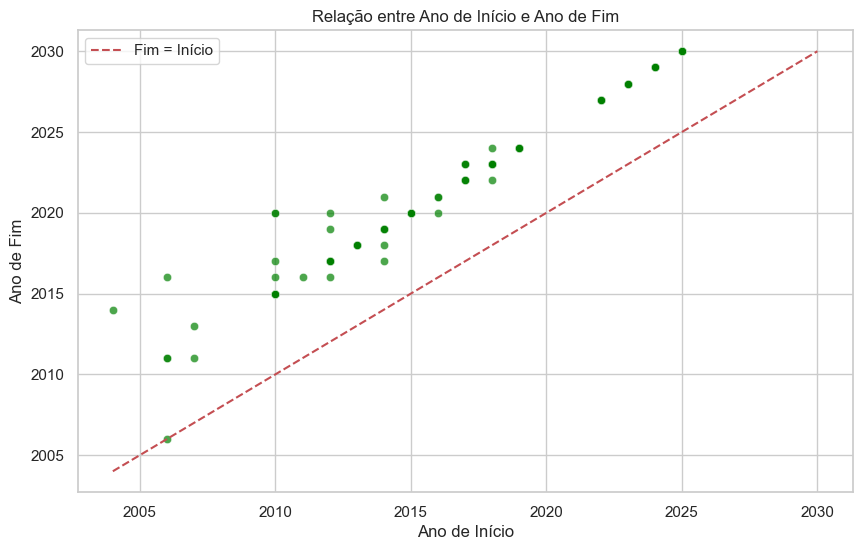

In [8]:
# 1. Histograma
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='panInicioAno', bins=15, kde=True, color='blue', label='Ano de Início')
sns.histplot(data=df, x='panFimAno', bins=15, kde=True, color='orange', label='Ano de Fim')
plt.title('Distribuição dos Anos de Início e Fim dos PANs')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend()
plt.show()

# 2. Boxplot
plt.figure(figsize=(10, 6))
df_melted = df.melt(value_vars=['panInicioAno', 'panFimAno'], var_name='Tipo de Ano', value_name='Ano')
sns.boxplot(x='Tipo de Ano', y='Ano', data=df_melted, hue='Tipo de Ano', palette='Set2', legend=False)
plt.title('Boxplot: Dispersão dos Anos de Início e Fim')
plt.show()

# 3. Gráfico de Dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='panInicioAno', y='panFimAno', alpha=0.7, color='green')
plt.title('Relação entre Ano de Início e Ano de Fim')
plt.xlabel('Ano de Início')
plt.ylabel('Ano de Fim')

min_ano = min(df['panInicioAno'].min(), df['panFimAno'].min())
max_ano = max(df['panInicioAno'].max(), df['panFimAno'].max())
if pd.notna(min_ano) and pd.notna(max_ano):
    plt.plot([min_ano, max_ano], [min_ano, max_ano], 'r--', label='Fim = Início')

plt.legend()
plt.show()